In [19]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração para exibir gráficos diretamente no notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

In [20]:
# Carregar o novo arquivo CSV
caminho_arquivo = '2025/base_senado_mineracao.csv'
df_bruto = pd.read_csv(caminho_arquivo, delimiter=';')

# Filtrar apenas o ano de exercício de 2025
df_2025 = df_bruto[df_bruto['ANO EXERCÍCIO'] == 2025].copy()

print(f"Total de registros em 2025: {df_2025.shape[0]}")
df_2025[['LOTAÇÃO EXERCÍCIO', 'HORAS_EXTRAS', 'REM_LIQUIDA', 'MES_REFERENCIA']].head()

Total de registros em 2025: 8937


,LOTAÇÃO EXERCÍCIO,HORAS_EXTRAS,REM_LIQUIDA,MES_REFERENCIA
363,GABINETE DA SENADORA IVETE DA SILVEIRA,0.0,1725.48,1
466,GABINETE DO SENADOR MAGNO MALTA,0.0,2745.10,1
471,GABINETE DO SENADOR MAGNO MALTA,0.0,2198.45,1
472,GABINETE DA LIDERANÇA DA BANCADA FEMININA,0.0,2293.04,1
473,GABINETE DA LIDERANÇA DO PODEMOS,0.0,1725.48,1


In [21]:
# Agregar por departamento e mês para consolidar os gastos reais
df_depto = df_bruto.groupby(['LOTAÇÃO EXERCÍCIO', 'MES_REFERENCIA']).agg({
    'HORAS_EXTRAS': 'sum',
    'REMUN_BASICA': 'sum',
    'REM_LIQUIDA': 'sum',
    'FUNCAO_NUMERICA': 'mean', # Média hierárquica do setor
    'VÍNCULO': 'count'         # Quantidade de funcionários no setor
}).reset_index()

# Renomear coluna de contagem para representar o tamanho do departamento
df_depto.rename(columns={'VÍNCULO': 'QTD_SERVIDORES'}, inplace=True)

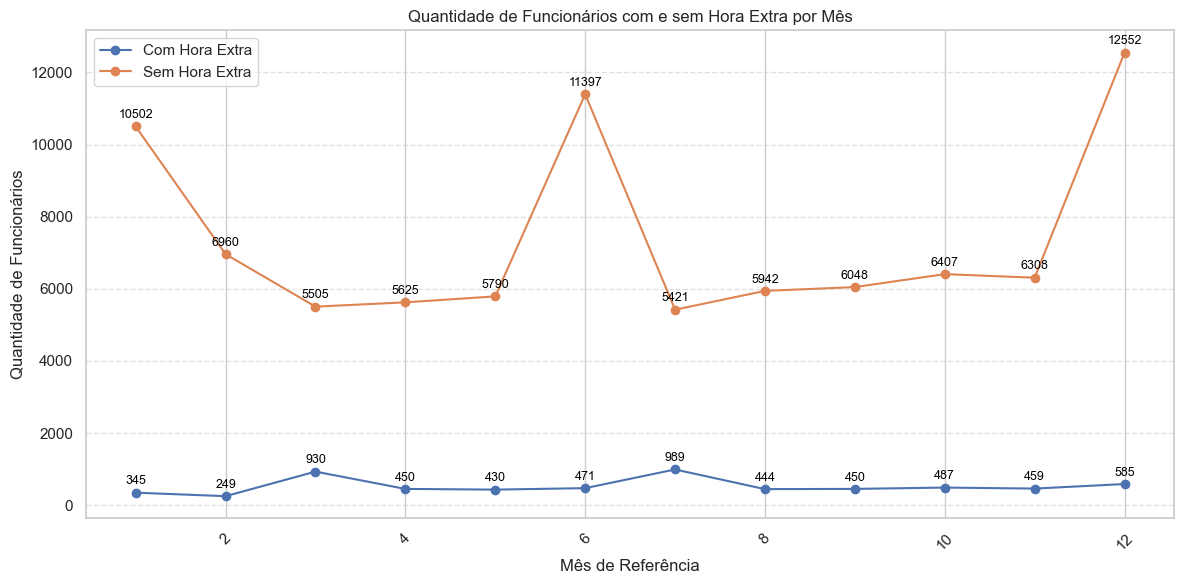

In [22]:
# Contagem mensal de funcionários com e sem hora extra
df_bruto['TEM_HORA_EXTRA'] = df_bruto['HORAS_EXTRAS'] > 0
contagem_mensal = (
    df_bruto.groupby(['MES_REFERENCIA', 'TEM_HORA_EXTRA'])['VÍNCULO']
      .count()
      .reset_index(name='QTD_FUNCIONARIOS')
)
contagem_mensal['TIPO'] = contagem_mensal['TEM_HORA_EXTRA'].map({True: 'Com Hora Extra', False: 'Sem Hora Extra'})
contagem_mensal = contagem_mensal.sort_values(['MES_REFERENCIA', 'TEM_HORA_EXTRA'])

plt.figure(figsize=(12,6))
for tipo, grupo in contagem_mensal.groupby('TIPO'):
    plt.plot(
        grupo['MES_REFERENCIA'],
        grupo['QTD_FUNCIONARIOS'],
        marker='o',
        label=tipo
    )
    for x, y in zip(grupo['MES_REFERENCIA'], grupo['QTD_FUNCIONARIOS']):
        plt.annotate(
            str(y),
            xy=(x, y),
            xytext=(0, 6),
            textcoords='offset points',
            ha='center',
            fontsize=9,
            color='black'
        )

plt.title('Quantidade de Funcionários com e sem Hora Extra por Mês')
plt.xlabel('Mês de Referência')
plt.ylabel('Quantidade de Funcionários')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [23]:
X = df_2025[['HORAS_EXTRAS']].values

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K=2, Coeficiente de Silhueta = 0.9890
K=3, Coeficiente de Silhueta = 0.9902
K=4, Coeficiente de Silhueta = 0.9907
K=5, Coeficiente de Silhueta = 0.9916
K=6, Coeficiente de Silhueta = 0.9911
K=7, Coeficiente de Silhueta = 0.9913
K=8, Coeficiente de Silhueta = 0.9917
K=9, Coeficiente de Silhueta = 0.9917
K=10, Coeficiente de Silhueta = 0.9920
K=11, Coeficiente de Silhueta = 0.9920
K=12, Coeficiente de Silhueta = 0.9918
K=13, Coeficiente de Silhueta = 0.9919
K=14, Coeficiente de Silhueta = 0.9922
K=15, Coeficiente de Silhueta = 0.9924
K=16, Coeficiente de Silhueta = 0.9924
K=17, Coeficiente de Silhueta = 0.9927
K=18, Coeficiente de Silhueta = 0.9930
K=19, Coeficiente de Silhueta = 0.9928
K=20, Coeficiente de Silhueta = 0.9928
K=21, Coeficiente de Silhueta = 0.9926
K=22, Coeficiente de Silhueta = 0.9927
K=23, Coeficiente de Silhueta = 0.9930
K=24, Coeficiente de Silhueta = 0.9930
K=25, Coeficiente de Silhueta = 0.9931
K=26, Coeficiente de Silhueta = 0.9930
K=27, Coeficiente de Silhueta = 0

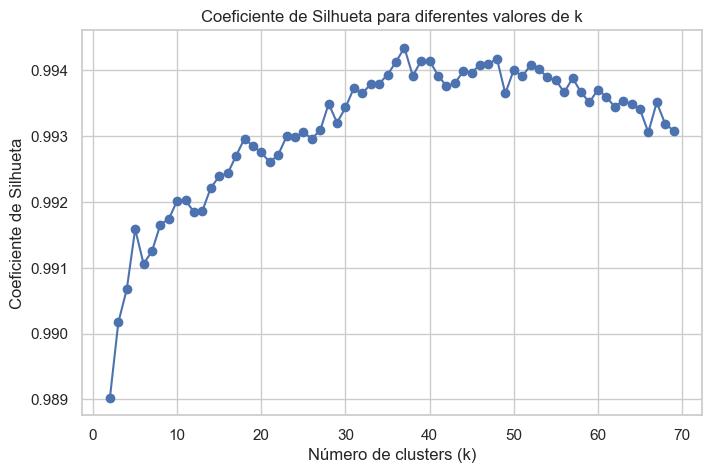

In [25]:
silhouette_scores = []
K = range(2, 70)  # testa de 2 a 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Coeficiente de Silhueta = {score:.4f}")

# Plotando gráfico da silhueta
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de Silhueta")
plt.title("Coeficiente de Silhueta para diferentes valores de k")
plt.show()

In [26]:
# Escolher o melhor k (maior silhueta)
best_k = K[silhouette_scores.index(max(silhouette_scores))]
print(f"\nNúmero ótimo de clusters: {best_k}")


Número ótimo de clusters: 37


In [27]:
""" Como a quantidade recomendada matemáticamente para os clusters é 37 e não
iremos conseguir visualmente distinguir essa quantidade alta de grupos iremos optar 
por 5 clusters e analizar esses agrupamentos
"""

' Como a quantidade recomendada matemáticamente para os clusters é 37 e não\niremos conseguir visualmente distinguir essa quantidade alta de grupos iremos optar \npor 5 clusters e analizar esses agrupamentos\n'

In [28]:
# Garantir que as colunas críticas sejam lidas como números (floats)
df_2025['HORAS_EXTRAS'] = pd.to_numeric(df_2025['HORAS_EXTRAS'], errors='coerce').fillna(0)
df_2025['REM_LIQUIDA'] = pd.to_numeric(df_2025['REM_LIQUIDA'], errors='coerce').fillna(0)

# Agrupando por Departamento e Mês para entender a flutuação ao longo de 2025
Agrupado_Mes = df_2025.groupby(['LOTAÇÃO EXERCÍCIO', 'MES_REFERENCIA']).agg(
    Total_Horas_Extras=('HORAS_EXTRAS', 'sum'),
    Total_Folha=('REM_LIQUIDA', 'sum')
).reset_index()

# Consolidação final por Departamento (Métricas do K-means)
df_departamentos = Agrupado_Mes.groupby('LOTAÇÃO EXERCÍCIO').agg(
    Gasto_Medio_HE=('Total_Horas_Extras', 'mean'),
    Volatilidade_HE=('Total_Horas_Extras', 'std'),
    Gasto_Total_Folha=('Total_Folha', 'mean')
).reset_index()

# Tratamento de valores nulos no Desvio Padrão (Volatilidade)
df_departamentos['Volatilidade_HE'] = df_departamentos['Volatilidade_HE'].fillna(0)

# Cálculo do impacto percentual das Horas Extras na folha do departamento
df_departamentos['Percentual_HE_Na_Folha'] = (df_departamentos['Gasto_Medio_HE'] / df_departamentos['Gasto_Total_Folha']) * 100
df_departamentos['Percentual_HE_Na_Folha'] = df_departamentos['Percentual_HE_Na_Folha'].fillna(0)

# Filtrar apenas departamentos que registraram gastos com HE em 2025
df_analise = df_departamentos[df_departamentos['Gasto_Medio_HE'] > 0].reset_index(drop=True)

print(f"Total de departamentos com Horas Extras em 2025: {df_analise.shape[0]}")
df_analise.head()

Total de departamentos com Horas Extras em 2025: 38


,LOTAÇÃO EXERCÍCIO,Gasto_Medio_HE,Volatilidade_HE,Gasto_Total_Folha,Percentual_HE_Na_Folha
0,BLOCO PARLAM. DEMOCRACIA (MDB/UNIÃO/PODEMOS/PSDB),476.470000,433.039939,32094.713750,1.484575
1,BLOCO PARLAMENTAR VANGUARDA (PL/NOVO),1726.918333,1355.833465,8579.193333,20.129146
2,COORDENAÇÃO DE EVENTOS,35.985000,88.144888,2989.206667,1.203831
3,DIRETORIA-EXECUTIVA DE GOV. CONTRAT. E LICITAT...,119.278889,357.836667,54495.978889,0.218876
4,GABINETE DA DGER,1070.375714,1428.635409,56298.100000,1.901264


In [29]:
# Variáveis que o K-means usará para comparar os setores
atributos = ['Gasto_Medio_HE', 'Volatilidade_HE', 'Percentual_HE_Na_Folha']
X = df_analise[atributos]

# Colocando os dados na mesma escala (Média=0, Desvio Padrão=1)
scaler = StandardScaler()
X_escalonado = scaler.fit_transform(X)

print("Dados prontos e normalizados!")

Dados prontos e normalizados!


In [30]:
# Definindo 5 grupos de comportamento
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Treinando o modelo e aplicando os rótulos de grupo 
df_analise['Cluster'] = kmeans.fit_predict(X_escalonado)

# Exibir a média de cada grupo para você entender o perfil de cada um
print("=== Perfil Médio de Cada Cluster ===")
print(df_analise.groupby('Cluster')[atributos].mean())

d:\Nova pasta\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


=== Perfil Médio de Cada Cluster ===
         Gasto_Medio_HE  Volatilidade_HE  Percentual_HE_Na_Folha
Cluster                                                         
0           1022.509660      1341.080761                2.817444
1           3801.998994      2368.758621               11.101114
2           1459.409167       888.630613               20.751601
3           2248.162468      1193.312518                8.557481
4            240.447811       456.394627                1.402782


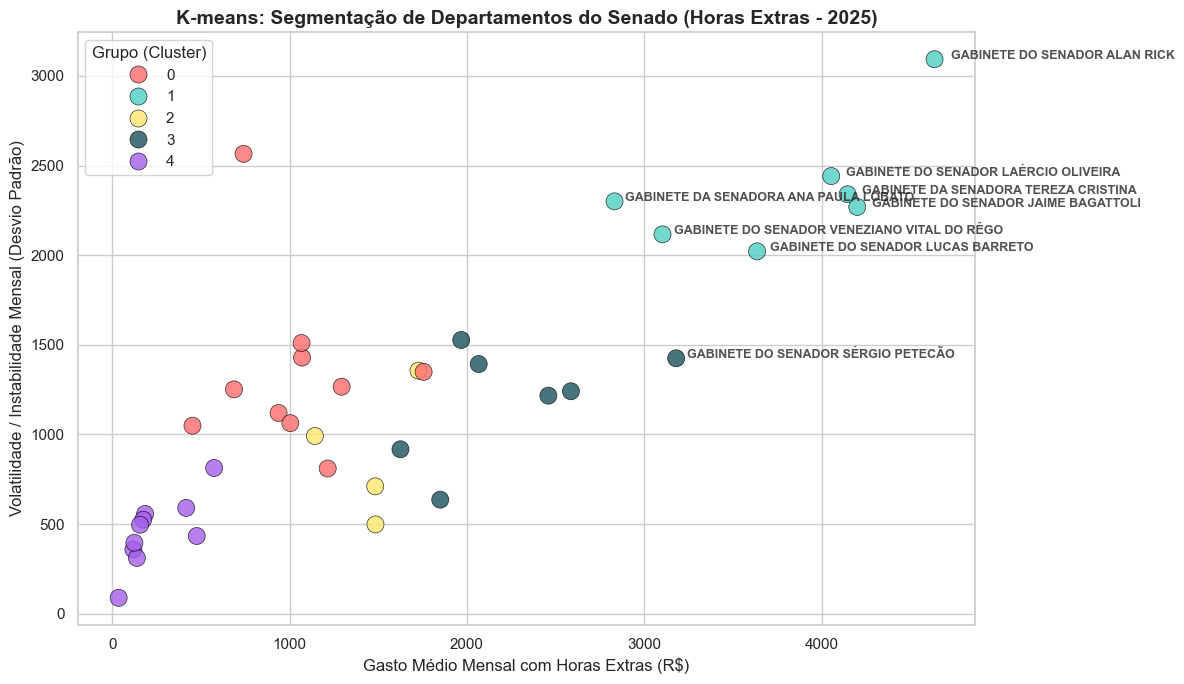

In [31]:
plt.figure(figsize=(12, 7))

# Plot dos pontos de cada departamento com as cores dos clusters

cores_clusters = {
    0: '#FF6B6B',  # (Grupo Crítico/Alto Risco)
    1: '#4ECDC4',  # (Grupo Risco Baixo)
    2: '#FFE66D',  # (Grupo Risco Médio)
    3: '#1A535C',  # (Grupo nulo/zero)
    4: '#A55EEA'   # (Grupo perfil/outliers)
}

sns.scatterplot(
    data=df_analise,
    x='Gasto_Medio_HE',
    y='Volatilidade_HE',
    hue='Cluster',
    palette=cores_clusters,
    s=150,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5
)

# Colocar etiquetas nos 8 maiores departamentos para melhor leitura
top_gastos = df_analise.nlargest(8, 'Gasto_Medio_HE')
for idx, row in top_gastos.iterrows():
    plt.text(
        row['Gasto_Medio_HE'] * 1.02,
        row['Volatilidade_HE'],
        row['LOTAÇÃO EXERCÍCIO'],
        fontsize=9,
        fontweight='semibold',
        alpha=0.8
    )

plt.title('K-means: Segmentação de Departamentos do Senado (Horas Extras - 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Gasto Médio Mensal com Horas Extras (R$)', fontsize=12)
plt.ylabel('Volatilidade / Instabilidade Mensal (Desvio Padrão)', fontsize=12)
plt.legend(title='Grupo (Cluster)')
plt.tight_layout()
plt.show()

In [32]:
# Criar tabela final ordenada pelo grupo e valor de gasto
relatorio_final = df_analise[['Cluster', 'LOTAÇÃO EXERCÍCIO', 'Gasto_Medio_HE', 'Percentual_HE_Na_Folha']].sort_values(by=['Cluster', 'Percentual_HE_Na_Folha'], ascending=[True, False])

# Exibe o topo da lista estruturada
relatorio_final.head(30)

,Cluster,LOTAÇÃO EXERCÍCIO,Gasto_Medio_HE,Percentual_HE_Na_Folha
11,0,GABINETE DA SENADORA TERESA LEITÃO,1293.789091,7.018946
27,0,GABINETE DO SENADOR ROGÉRIO CARVALHO,1214.981667,4.248640
9,0,GABINETE DA SENADORA DAMARES ALVES,938.232727,3.851791
36,0,SERVIÇO DE PAGAMENTO A FORNECEDORES,1067.590000,3.160782
37,0,TERCEIRA-SECRETARIA,1004.471000,2.140146
4,0,GABINETE DA DGER,1070.375714,1.901264
32,0,PRESIDÊNCIA DO SENADO FEDERAL,740.605833,1.672880
10,0,GABINETE DA SENADORA DRA. EUDÓCIA,1755.820000,1.497515
35,0,SERVIÇO DE CONTROLE OPERACIONAL,452.548571,1.354521
14,0,GABINETE DO SENADOR ANGELO CORONEL,686.682000,1.327952


In [33]:
# normalizar chave para evitar diferenças de espaço/case
df_bruto['LOTAÇÃO EXERCÍCIO'] = df_bruto['LOTAÇÃO EXERCÍCIO'].astype(str).str.strip()
df_analise['LOTAÇÃO EXERCÍCIO'] = df_analise['LOTAÇÃO EXERCÍCIO'].astype(str).str.strip()

# contar servidores únicos por departamento
qtd_servidores = (
    df_bruto.groupby('LOTAÇÃO EXERCÍCIO')['VÍNCULO']
    .nunique()
    .reset_index(name='QTD_SERVIDORES')
)

# limpar colunas antigas antes do merge para evitar colunas duplicadas
qtd_cols = [c for c in df_analise.columns if c.startswith('QTD_SERVIDORES')]
if qtd_cols:
    df_analise = df_analise.drop(columns=qtd_cols)

# juntar ao df_analise
df_analise = df_analise.merge(qtd_servidores, on='LOTAÇÃO EXERCÍCIO', how='left')

# evitar divisão por zero/NaN
df_analise['QTD_SERVIDORES'] = df_analise['QTD_SERVIDORES'].fillna(0).astype(int)
df_analise['HE_Por_Servidor'] = (
    df_analise['Gasto_Medio_HE']
    .div(df_analise['QTD_SERVIDORES'].replace(0, np.nan))
    .fillna(0)
)

In [34]:
# =========================================================================
# 1. NORMALIZAÇÃO RIGOROSA DAS CHAVES (Garante casamento perfeito no Merge)
# =========================================================================
df_bruto['LOTAÇÃO EXERCÍCIO'] = df_bruto['LOTAÇÃO EXERCÍCIO'].astype(str).str.strip().str.upper()
df_analise['LOTAÇÃO EXERCÍCIO'] = df_analise['LOTAÇÃO EXERCÍCIO'].astype(str).str.strip().str.upper()

# =========================================================================
# 2. CONTAGEM REAL DE SERVIDORES (Agrupando por setor e contando linhas)
# =========================================================================
# Usamos .size() para contar o número total de linhas (funcionários) por setor.
# Como a base tem 12 meses, dividimos por 12 para ter a média real de funcionários ativos por mês no setor.
qtd_servidores = (
    df_bruto.groupby('LOTAÇÃO EXERCÍCIO')
    .size()
    .reset_index(name='TOTAL_REGISTROS')
)

# Encontrando a média de servidores por mês (evita multiplicar o tamanho do setor por 12)
qtd_servidores['QTD_SERVIDORES'] = (qtd_servidores['TOTAL_REGISTROS'] / 12).round().astype(int)

# Mantendo apenas o que importa para o merge
qtd_servidores = qtd_servidores[['LOTAÇÃO EXERCÍCIO', 'QTD_SERVIDORES']]

# =========================================================================
# 3. LIMPEZA DE COLUNAS DUPLICADAS E JUNÇÃO (MERGE)
# =========================================================================
# Remove colunas antigas de quantidade de servidores se elas já existirem no df_analise
cols_para_remover = [c for c in df_analise.columns if 'QTD_SERVIDORES' in c or 'HE_Por_Servidor' in c]
if cols_para_remover:
    df_analise = df_analise.drop(columns=cols_para_remover)

# Realiza a junção exata das informações
df_analise = df_analise.merge(qtd_servidores, on='LOTAÇÃO EXERCÍCIO', how='left')

# =========================================================================
# 4. CÁLCULO DA MÉTRICA PROPORCIONAL (Evitando divisões por zero)
# =========================================================================
df_analise['QTD_SERVIDORES'] = df_analise['QTD_SERVIDORES'].fillna(0).astype(int)

# Onde for 0, temporariamente vira NaN para o cálculo não quebrar, depois preenchemos com 0
df_analise['HE_Por_Servidor'] = (
    df_analise['Gasto_Medio_HE']
    .div(df_analise['QTD_SERVIDORES'].replace(0, np.nan))
    .fillna(0)
)

# =========================================================================
# 5. VALIDAÇÃO DOS DADOS (PROVA REAL)
# =========================================================================
print("-> Validação de dados para o Gabinete do Senador Alan Rick:")
gabinete_teste = df_analise[df_analise['LOTAÇÃO EXERCÍCIO'].str.contains('ALAN RICK', na=False)]
print(gabinete_teste[['LOTAÇÃO EXERCÍCIO', 'QTD_SERVIDORES', 'Gasto_Medio_HE', 'HE_Por_Servidor']])

-> Validação de dados para o Gabinete do Senador Alan Rick:
                LOTAÇÃO EXERCÍCIO  QTD_SERVIDORES  Gasto_Medio_HE  \
13  GABINETE DO SENADOR ALAN RICK              21     4637.571818   

    HE_Por_Servidor  
13       220.836753  


In [35]:
# Criar tabela com valores de horas extras e quantidade de servidores por departamento
# Use head() para ver o topo da tabela; remova head() se quiser ver tudo.
tabela_departamentos = df_analise[
    ['LOTAÇÃO EXERCÍCIO', 'QTD_SERVIDORES', 'Gasto_Medio_HE', 'HE_Por_Servidor', 'Percentual_HE_Na_Folha']
].sort_values(by='Percentual_HE_Na_Folha', ascending=False).reset_index(drop=True)

display(tabela_departamentos.head(50))

,LOTAÇÃO EXERCÍCIO,QTD_SERVIDORES,Gasto_Medio_HE,HE_Por_Servidor,Percentual_HE_Na_Folha
0,GABINETE DO SENADOR JAYME CAMPOS,36,1484.478333,41.235509,22.331316
1,GABINETE DO SENADOR IRAJÁ,29,1483.200000,51.144828,21.129555
2,BLOCO PARLAMENTAR VANGUARDA (PL/NOVO),12,1726.918333,143.909861,20.129146
3,GABINETE DA SENADORA TEREZA CRISTINA,20,4147.243636,207.362182,19.815991
4,GABINETE DO SENADOR FERNANDO FARIAS,16,1143.040000,71.440000,19.416385
5,GABINETE DO SENADOR JAIME BAGATTOLI,13,4201.556667,323.196667,15.394455
6,GABINETE DA SENADORA ANA PAULA LOBATO,13,2832.685833,217.898910,12.540284
7,GABINETE DO SENADOR STYVENSON VALENTIM,12,2459.667273,204.972273,12.097499
8,GABINETE DO SENADOR VANDERLAN CARDOSO,14,1625.451667,116.103690,10.102967
9,GABINETE DO SENADOR PEDRO CHAVES,5,1849.762500,369.952500,9.846020


In [37]:
# 1. Definir o que é um departamento de "Alto Risco" (Ex: Gastou acima do porcentual de 80 Horas Extras)
limite_critico = df_analise['Gasto_Medio_HE'].quantile(0.80)
df_analise['ALTO_RISCO'] = (df_analise['Gasto_Medio_HE'] > limite_critico).astype(int)

# 2. Selecionar as variáveis preditoras (X) e a variável alvo (y)
# (Usando as características agregadas do departamento para prever o risco)
X = df_analise[['Percentual_HE_Na_Folha', 'QTD_SERVIDORES']] # Adicione aqui outras métricas do setor se houver
y = df_analise['ALTO_RISCO']

# 3. Dividir em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


[SUCESSO] Modelo treinado!
Métrica AUC-ROC obtida: 0.8889


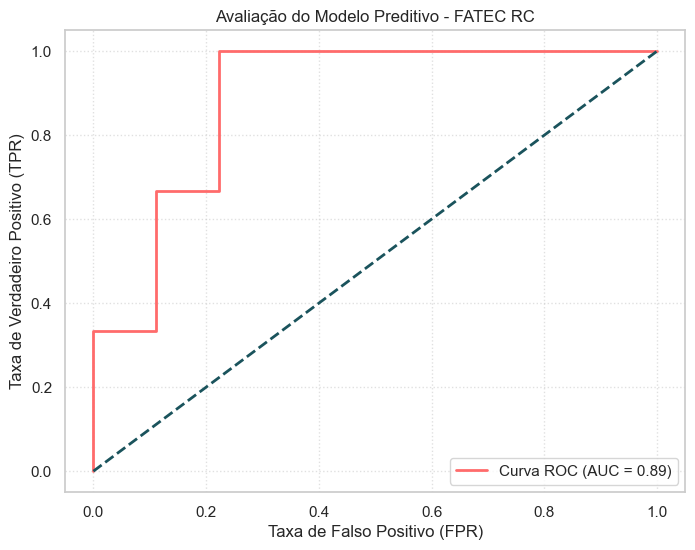

In [38]:


# 4. Inicializar e treinar o modelo Random Forest
modelo_risco = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_risco.fit(X_train, y_train)

# 5. Predizer as probabilidades das classes (essencial para o cálculo da curva AUC-ROC)
probabilidades = modelo_risco.predict_proba(X_test)[:, 1]

# 6. Calcular o Score AUC-ROC
auc_score = roc_auc_score(y_test, probabilidades)
print(f"\n[SUCESSO] Modelo treinado!")
print(f"Métrica AUC-ROC obtida: {auc_score:.4f}")

# 7. Gerar e Plotar o gráfico da Curva ROC exigida no projeto
fpr, tpr, thresholds = roc_curve(y_test, probabilidades)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#FF6B6B', lw=2, label=f'Curva ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='#1A535C', lw=2, linestyle='--')
plt.xlabel('Taxa de Falso Positivo (FPR)')
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
plt.title('Avaliação do Modelo Preditivo - FATEC RC')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

C:\Users\brend\AppData\Local\Temp\ipykernel_13852\2896082573.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


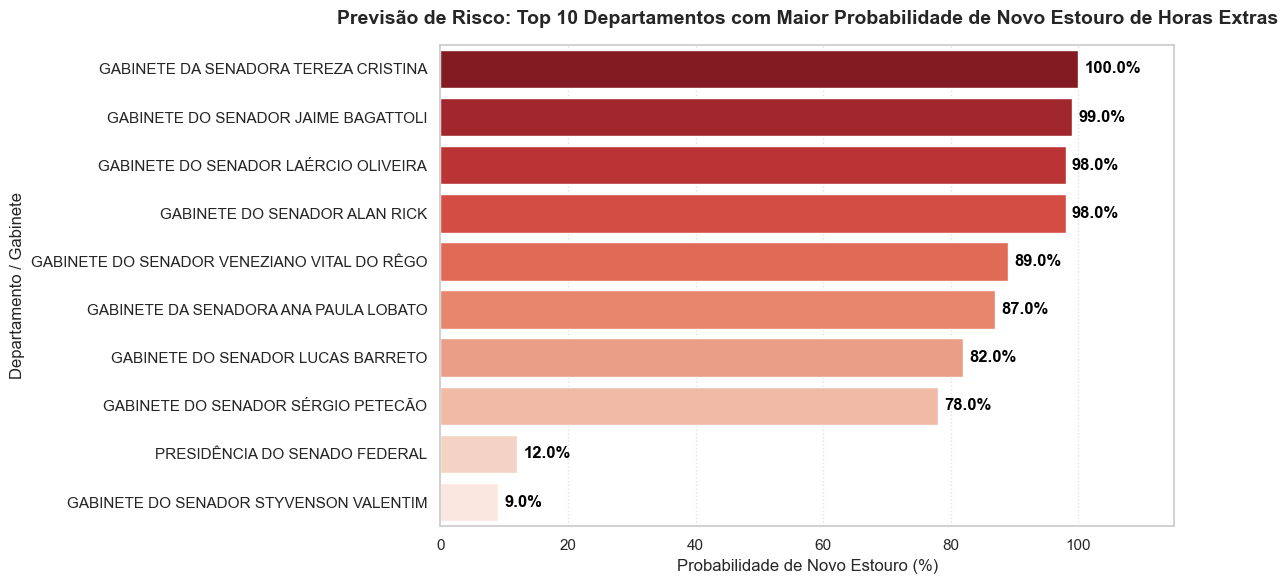


              TABELA DE APURAÇÃO PREDITIVA DE RISCO ORÇAMENTÁRIO
                             LOTAÇÃO EXERCÍCIO PROB_ESTOURO_% Gasto_Medio_HE  QTD_SERVIDORES
0         GABINETE DA SENADORA TEREZA CRISTINA        100.00%    R$ 4,147.24              20
1          GABINETE DO SENADOR JAIME BAGATTOLI         99.00%    R$ 4,201.56              13
2         GABINETE DO SENADOR LAÉRCIO OLIVEIRA         98.00%    R$ 4,054.78              28
3                GABINETE DO SENADOR ALAN RICK         98.00%    R$ 4,637.57              21
4  GABINETE DO SENADOR VENEZIANO VITAL DO RÊGO         89.00%    R$ 3,103.37              65
5        GABINETE DA SENADORA ANA PAULA LOBATO         87.00%    R$ 2,832.69              13
6            GABINETE DO SENADOR LUCAS BARRETO         82.00%    R$ 3,636.78              37
7           GABINETE DO SENADOR SÉRGIO PETECÃO         78.00%    R$ 3,180.43              24


In [39]:

# 1. Definição do Alvo (Gasto acima do percentil 80 é considerado estouro/alto risco)
limite_critico = df_analise['Gasto_Medio_HE'].quantile(0.80)
df_analise['ALTO_RISCO'] = (df_analise['Gasto_Medio_HE'] > limite_critico).astype(int)

# 2. Atributos Preditores
features = ['Gasto_Medio_HE', 'Volatilidade_HE', 'Percentual_HE_Na_Folha', 'QTD_SERVIDORES', 'HE_Por_Servidor']
X = df_analise[features]
y = df_analise['ALTO_RISCO']

# 3. Treinar o modelo com a base completa para mapear o cenário atual do Senado
modelo_risco = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_risco.fit(X, y)

# 4. Predizer a probabilidade real de cada departamento ter um NOVO ESTOURO
# O predict_proba retorna a chance de ser 0 e a chance de ser 1. Pegamos a chance de ser 1 (índice 1)
df_analise['PROB_ESTOURO_%'] = modelo_risco.predict_proba(X)[:, 1] * 100

# 5. Criar o Ranking dos Departamentos mais perigosos para o orçamento futuro
ranking_estouro = df_analise[['LOTAÇÃO EXERCÍCIO', 'PROB_ESTOURO_%', 'Gasto_Medio_HE', 'QTD_SERVIDORES']].sort_values(by='PROB_ESTOURO_%', ascending=False)

# ========================================================
# NOVO GRÁFICO: OS 10 DEPARTAMENTOS COM MAIOR RISCO DE ESTOURO
# ========================================================
plt.figure(figsize=(12, 6))
top_10_risco = ranking_estouro.head(10)

# Criando o gráfico de barras
ax = sns.barplot(
    x='PROB_ESTOURO_%', 
    y='LOTAÇÃO EXERCÍCIO', 
    data=top_10_risco, 
    palette=sns.color_palette("Reds_r", n_colors=10)
)

# Adicionando os valores das probabilidades na ponta das barras
for i, v in enumerate(top_10_risco['PROB_ESTOURO_%']):
    ax.text(v + 1, i, f"{v:.1f}%", va='center', fontweight='bold', color='black')

plt.title('Previsão de Risco: Top 10 Departamentos com Maior Probabilidade de Novo Estouro de Horas Extras', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Probabilidade de Novo Estouro (%)', fontsize=12)
plt.ylabel('Departamento / Gabinete', fontsize=12)
plt.xlim(0, 115)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# ========================================================
# EXIBIÇÃO DA TABELA DE APURAÇÃO DE RISCO
# ========================================================
print("\n" + "="*80)
print("              TABELA DE APURAÇÃO PREDITIVA DE RISCO ORÇAMENTÁRIO")
print("="*80)
# Mostra os setores com mais de 70% de chance de estouro
setores_criticos = ranking_estouro[ranking_estouro['PROB_ESTOURO_%'] > 70].reset_index(drop=True)
print(setores_criticos.to_string(formatters={'PROB_ESTOURO_%': '{:.2f}%'.format, 'Gasto_Medio_HE': 'R$ {:,.2f}'.format}))